In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE

In [25]:
data_name = "HAR"

train_dataset = torch.load(f"./dataset/classification/{data_name}/train.pt")
val_dataset = torch.load(f"./dataset/classification/{data_name}/val.pt")
test_dataset = torch.load(f"./dataset/classification/{data_name}/test.pt")

In [26]:
data_name = "HAR"

id_results = np.load(f"{data_name}_n3_h2_id.npz")
id_results = {key: id_results[key] for key in id_results.files}

ood_results = np.load(f"{data_name}_n3_h2_ood.npz")
ood_results = {key: ood_results[key] for key in ood_results.files}

In [27]:
analysis_results = {}

keys = id_results.keys()
for key in keys:
    analysis_results[key] = np.concatenate([id_results[key], ood_results[key]], axis=0)

In [28]:
analysis_results['targets'].shape, analysis_results['preds'].shape

((2947,), (2947,))

In [29]:
id_acc = np.sum(id_results['targets'] == id_results['preds']) / len(id_results['targets'])
ood_acc = np.sum(ood_results['targets'] == ood_results['preds']) / len(ood_results['targets'])
analysis_acc = np.sum(analysis_results['targets'] == analysis_results['preds']) / len(analysis_results['targets'])

print(f"ID Accuracy:       {id_acc:.4f}")
print(f"OOD Accuracy:      {ood_acc:.4f}")
print(f"Combined Accuracy: {analysis_acc:.4f}")

ID Accuracy:       0.8987
OOD Accuracy:      0.0000
Combined Accuracy: 0.5928


In [30]:
analysis_results.get("max_conf").max()

0.9999958

# Plot functions

In [31]:
def plot_score_distributions(id_results, ood_results, score_type='max_conf'):
    """
    Compares the distribution of scores between In-Distribution and OOD data.
    """
    id_scores = id_results[score_type]
    ood_scores = ood_results[score_type]
    
    plt.figure(figsize=(10, 6))
    
    # Define common bins for both datasets
    bins = np.linspace(min(id_scores.min(), ood_scores.min()), 
                       max(id_scores.max(), ood_scores.max()), 50)
    
    # Plotting histograms
    plt.hist(id_scores, bins=bins, alpha=0.5, label='In-Distribution', 
             color='skyblue', edgecolor='navy', density=True)
    plt.hist(ood_scores, bins=bins, alpha=0.5, label='Out-of-Distribution', 
             color='salmon', edgecolor='darkred', density=True)
    
    plt.title(f'OOD Detection Analysis: {score_type.upper()} Distribution', fontsize=14)
    plt.xlabel('Confidence Score', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [32]:
def plot_per_class_confidence(analysis_results):
    """
    Shows the distribution of max_conf for every class in the results.
    Useful for seeing which known classes are 'overconfident'.
    """
    targets = analysis_results['targets']
    confidences = analysis_results['max_conf']
    unique_classes = sorted(np.unique(targets))
    
    data_to_plot = [confidences[targets == cls] for cls in unique_classes]
    
    plt.figure(figsize=(12, 6))
    plt.boxplot(data_to_plot, patch_artist=True, 
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
    
    plt.xticks(range(1, len(unique_classes) + 1), [f"Class {int(c)}" for c in unique_classes])
    plt.title('Confidence Variation across Classes', fontsize=14)
    plt.ylabel('Max Softmax Probability', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()

In [33]:
def plot_reliability_curve(analysis_results, n_bins=10):
    """
    Plots expected calibration: Accuracy vs. Confidence.
    """
    confidences = analysis_results['max_conf']
    targets = analysis_results['targets']
    preds = analysis_results['preds']
    accuracies = (preds == targets)
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_accs = []
    bin_confs = []
    
    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        if np.any(mask):
            bin_accs.append(np.mean(accuracies[mask]))
            bin_confs.append(np.mean(confidences[mask]))
            
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
    plt.plot(bin_confs, bin_accs, marker='o', linewidth=2, color='darkorange', label='Model')
    
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Reliability Diagram')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

In [34]:
# The probability that a random ID sample gets a higher score than a random OOD sample.

def plot_auroc_manual(id_results, ood_results, score_type='max_conf'):
    """
    Calculates and plots AUROC without sklearn.
    id_results: dict from get_detailed_analysis_dict (In-Distribution)
    ood_results: dict from get_detailed_analysis_dict (Out-Of-Distribution)
    score_type: 'max_conf' or 'energy'
    """
    # Extract the score arrays
    id_scores = id_results[score_type]
    ood_scores = ood_results[score_type]
    
    # 1. Combine all scores to find every potential threshold
    all_scores = np.concatenate([id_scores, ood_scores])
    
    # unique_scores is the set of all confidence values the model actually produced
    unique_scores = np.unique(all_scores)
    
    # Sort thresholds from high (1.0) to low (0.0)
    thresholds = np.sort(unique_scores)[::-1]
    
    tpr_list = []
    fpr_list = []
    
    n_id = len(id_scores)
    n_ood = len(ood_scores)
    
    # 2. Sweep through thresholds to calculate TPR and FPR
    for t in thresholds:
        # True Positives: ID samples correctly identified as ID (score >= threshold)
        tp = np.sum(id_scores >= t)
        # False Positives: OOD samples incorrectly identified as ID (score >= threshold)
        fp = np.sum(ood_scores >= t)
        
        tpr_list.append(tp / n_id)
        fpr_list.append(fp / n_ood)
    
    # Convert to arrays for calculation
    tpr = np.array(tpr_list)
    fpr = np.array(fpr_list)
    
    # 3. Calculate AUROC using the Trapezoidal Rule
    # This integrates the area under the TPR-FPR curve
    auc_score = np.trapz(tpr, fpr)

    # 4. Plotting
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (OOD accepted as ID)')
    plt.ylabel('True Positive Rate (ID correctly accepted)')
    plt.title(f'OOD Detection Performance: {score_type}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()

    return auc_score

In [35]:
def plot_latent_clusters(analysis_results, title="TimeDRL Latent Space Visualization"):
    """
    Reduces 128D latents to 2D and plots them.
    """
    # 1. Extract data
    latents = analysis_results['latents']
    targets = analysis_results['targets']
    
    print(f"Reducing {latents.shape[0]} samples from {latents.shape[1]}D to 2D...")
    
    # 2. Run t-SNE
    # perplexity: balance between local and global aspects of the data
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
    latents_2d = tsne.fit_transform(latents)
    
    # 3. Plotting
    plt.figure(figsize=(10, 7))
    
    # Get unique classes to handle the coloring
    unique_classes = np.unique(targets)
    
    for cls in unique_classes:
        idx = (targets == cls)
        # Check if this class was one of the OOD ones (you said you removed 2 from training)
        # We can mark them with a different marker or transparency
        plt.scatter(
            latents_2d[idx, 0], 
            latents_2d[idx, 1], 
            label=f"Class {int(cls)}",
            alpha=0.6, 
            edgecolors='w',
            s=30
        )
    
    plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(title)
    plt.xlabel("t-SNE Feature 1")
    plt.ylabel("t-SNE Feature 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [36]:
def add_energy_to_results(results, T=1.0):
    logits = torch.from_numpy(results['logits'])
    # Energy = -T * log(sum(exp(logit/T)))
    energy = -T * torch.logsumexp(logits / T, dim=1).numpy()
    results['energy'] = energy
    return results

# Then you can run:
# id_res = add_energy_to_results(id_res)
# ood_res = add_energy_to_results(ood_res)
# plot_score_distributions(id_res, ood_res, score_type='energy')

In [37]:
def find_optimal_threshold(id_results, ood_results, score_type='max_conf'):
    id_scores = id_results[score_type]
    ood_scores = ood_results[score_type]
    
    thresholds = np.linspace(0, 1, 100)
    best_j = -1
    opt_t = 0
    
    for t in thresholds:
        tpr = np.sum(id_scores >= t) / len(id_scores)
        fpr = np.sum(ood_scores >= t) / len(ood_scores)
        j = tpr - fpr
        if j > best_j:
            best_j = j
            opt_t = t
            
    print(f"Optimal threshold for {score_type}: {opt_t:.4f}")
    return opt_t

In [38]:
# tpr = id as id / all id
# fpr = ood as id / all ood

def plot_fpr95_metric(id_results, ood_results, score_type='max_conf'):
    """
    Calculates and visualizes the FPR at 95% TPR.
    Note: For 'energy', ensure you pass neg_energy so that higher = ID.
    """
    id_scores = np.sort(id_results[score_type])
    ood_scores = ood_results[score_type]
    
    # 1. Find the threshold for 95% TPR
    # To keep 95% of ID, we find the 5th percentile of ID scores
    # (Since scores are sorted ascending, 5% of the way in is the cutoff)
    threshold_95tpr = np.percentile(id_scores, 5)
    
    # 2. Calculate FPR at this threshold
    # FPR = (OOD samples >= threshold) / (Total OOD samples)
    fps = np.sum(ood_scores >= threshold_95tpr)
    fpr95 = (fps / len(ood_scores)) * 100
    
    # 3. Visualization
    plt.figure(figsize=(10, 6))
    
    # Plot histograms
    bins = np.linspace(min(id_scores.min(), ood_scores.min()), 
                       max(id_scores.max(), ood_scores.max()), 50)
    
    plt.hist(id_scores, bins=bins, alpha=0.5, label='ID Scores', color='blue', density=True)
    plt.hist(ood_scores, bins=bins, alpha=0.5, label='OOD Scores', color='red', density=True)
    
    # Draw the 95% TPR Threshold line
    plt.axvline(threshold_95tpr, color='black', linestyle='--', linewidth=2, 
                label=f'Threshold (95% TPR): {threshold_95tpr:.4f}')
    
    # Highlight the "Leakage" area (OOD samples above threshold)
    plt.fill_betweenx([0, plt.gca().get_ylim()[1]], threshold_95tpr, bins.max(), 
                      color='red', alpha=0.1, label='OOD Leakage (FPR)')
    
    plt.title(f'FPR at 95% TPR: {fpr95:.2f}%', fontsize=14)
    plt.xlabel(f'Score ({score_type})')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    print(f"--- OOD Metric: {score_type} ---")
    print(f"Threshold for 95% TPR: {threshold_95tpr:.4f}")
    print(f"FPR at 95% TPR: {fpr95:.2f}%")
    
    return fpr95

# Plot results

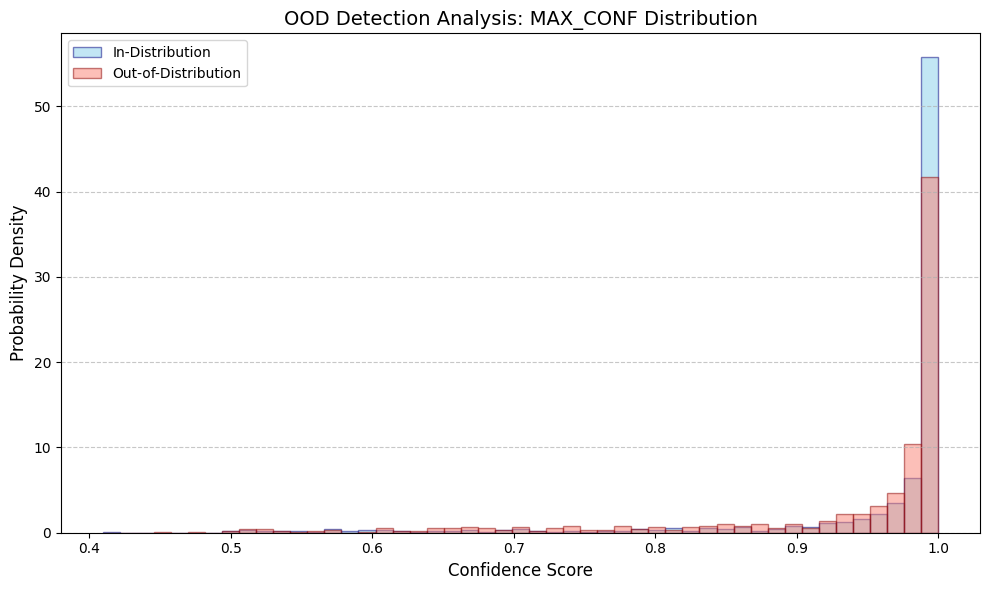

In [39]:
plot_score_distributions(id_results, ood_results, score_type='max_conf')

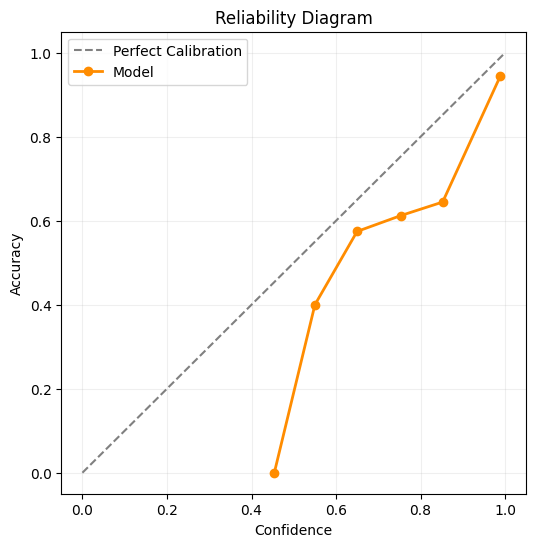

In [40]:
plot_reliability_curve(id_results)

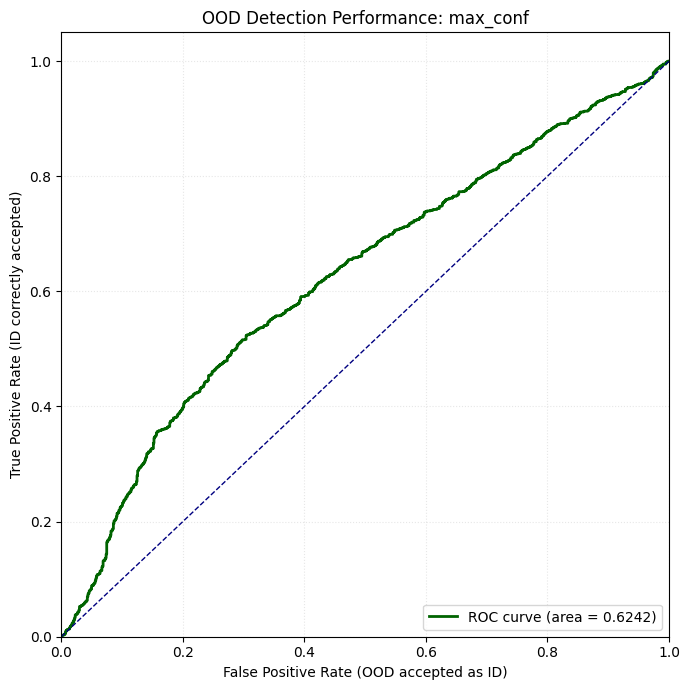

0.6242271128999832

In [41]:
plot_auroc_manual(id_results, ood_results, score_type='max_conf')

Reducing 1944 samples from 256D to 2D...


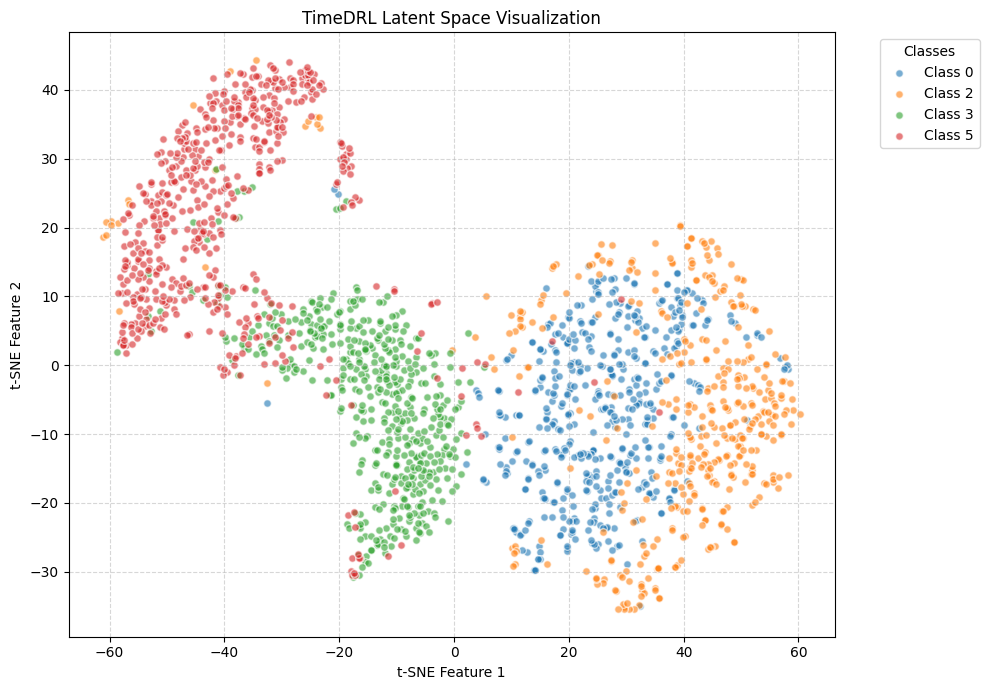

In [42]:
plot_latent_clusters(id_results)

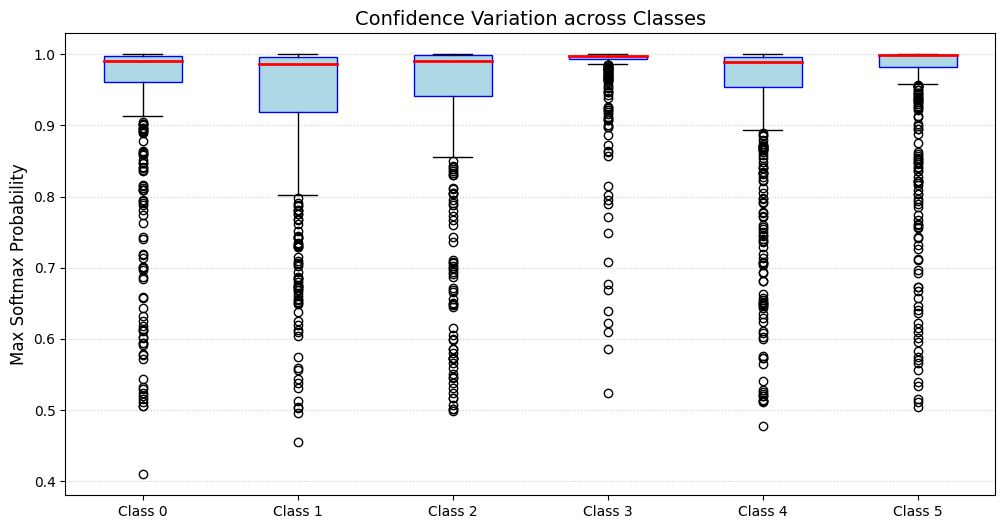

In [43]:
plot_per_class_confidence(analysis_results)

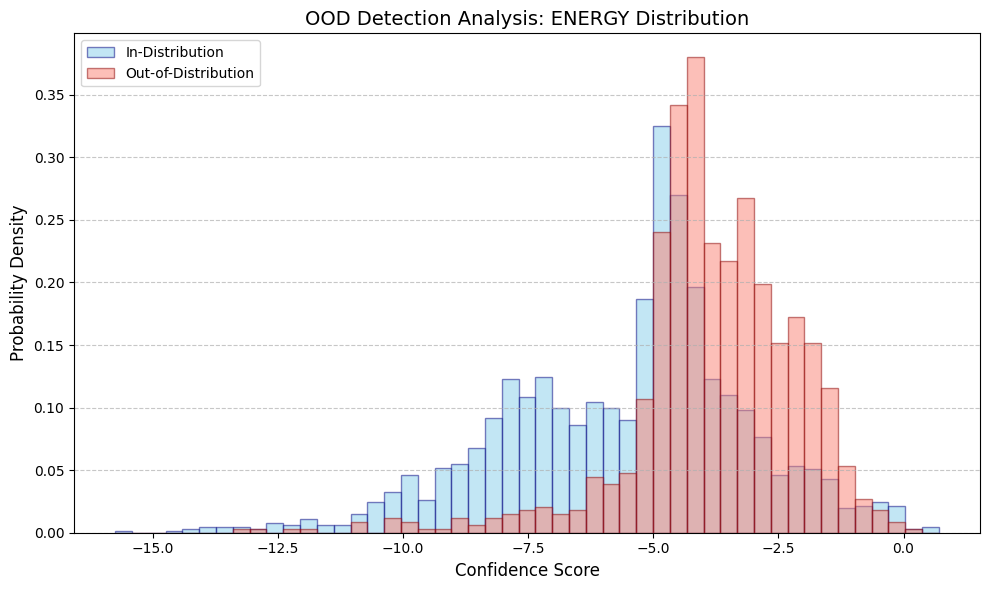

In [44]:
id_res = add_energy_to_results(id_results)
ood_res = add_energy_to_results(ood_results)
plot_score_distributions(id_res, ood_res, score_type='energy')

In [45]:
find_optimal_threshold(id_results, ood_results, score_type='max_conf')

Optimal threshold for max_conf: 0.9899


0.98989898989899

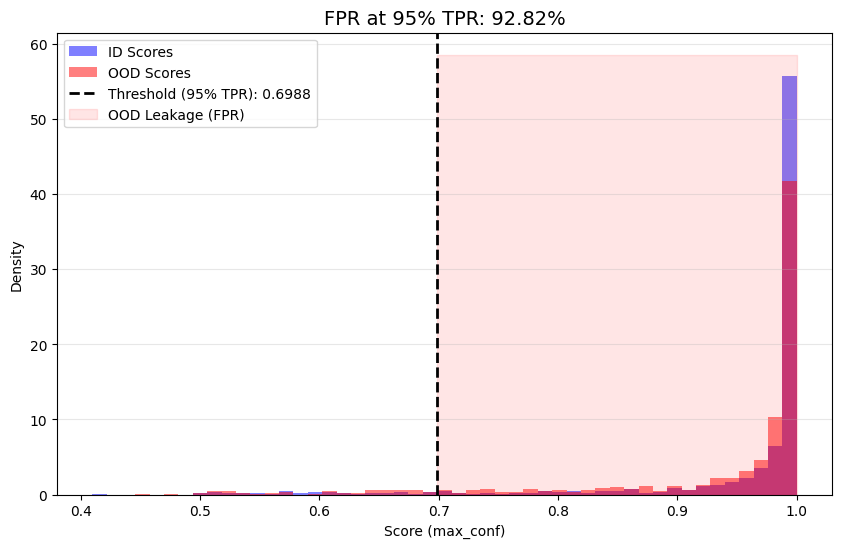

--- OOD Metric: max_conf ---
Threshold for 95% TPR: 0.6988
FPR at 95% TPR: 92.82%


92.82153539381855

In [46]:
plot_fpr95_metric(id_results, ood_results, score_type='max_conf')